# 04 - Classification: Predicting "Highly Rated" Restaurants (PuneBite Analyzer)

**Objective:** build and compare classification models that predict whether a restaurant is *highly rated* (rating >= 4.0).
**Input:** `data/processed/restaurants_clean.csv`
**Output:** model comparison, the best model saved to `ml/models/`
**Syllabus link:** Unit V (Logistic Regression, KNN, SVM, Decision Tree, ensembles, confusion matrix, accuracy, precision, recall, F1, ROC-AUC); Unit IV (train-test split, K-Fold validation, overfitting/underfitting); Lab 5.

## Two decisions that shape this notebook

1. **Imbalance.** Only about 11% of rated restaurants reach 4.0. A model that always says "not highly rated" would be 89% accurate and completely useless. So we judge models by **F1, precision, recall, and ROC-AUC**, not accuracy alone.
2. **The `votes` trap.** Votes are strongly tied to rating (notebook 02), but a *new* restaurant has no votes. So we build two scenarios:
   - **Scenario A (with votes):** "Which existing restaurants are highly rated?" (best possible accuracy)
   - **Scenario B (no votes):** "Will a restaurant with these features (type, price, location, amenities) be highly rated?" This is the one the **Opening Advisor** feature uses.

**Leakage rule:** the star-percentage columns and `spam_review_count` are never used as inputs.

In [1]:
import os, sys, json, time, warnings
sys.path.append(os.path.abspath(".."))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import sklearn

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, cross_val_predict, validation_curve
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.base import clone
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
                             average_precision_score, confusion_matrix, ConfusionMatrixDisplay,
                             RocCurveDisplay, PrecisionRecallDisplay, precision_recall_curve, classification_report)
from sklearn.inspection import permutation_importance

from ml import features as feat

pd.set_option("display.width", 200)
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

df = pd.read_csv("../data/processed/restaurants_clean.csv")
cols = list(df.columns)
amenity_cols = cols[cols.index("star1_pct") + 1 : cols.index("spam_review_count")]
rated = df[df["has_rating"]].copy().reset_index(drop=True)
print("Rated restaurants:", len(rated))

Rated restaurants: 7669


## 1. Define the target

In [2]:
y = (rated["rating"] >= 4.0).astype(int)
print(y.value_counts().rename({0: "not highly rated", 1: "highly rated"}))
print(f"Share of highly rated: {y.mean():.1%}")

rating
not highly rated    6811
highly rated         858
Name: count, dtype: int64
Share of highly rated: 11.2%


## 2. Build the features
`ml/features.py` picks the features: cost, number of cuisines/amenities, payment flags, restaurant type, locality (top 30, others grouped as "Other"), the 15 most common cuisines, and amenities that occur in at least 1% of restaurants. Categorical columns are one-hot encoded and numbers are scaled inside a pipeline, so no information leaks from the test set.

In [3]:
spec = feat.fit_feature_spec(df, amenity_cols)
X_votes, info_votes = feat.make_features(rated, spec, with_votes=True)    # Scenario A
X_novotes, info_novotes = feat.make_features(rated, spec, with_votes=False)  # Scenario B

print("Scenario A (with votes):", X_votes.shape, "| Scenario B (no votes):", X_novotes.shape)
print("Amenities kept:", len(spec["amenity_keep"]), "| Top cuisines:", len(spec["top_cuisines"]),
      "| Localities:", len(spec["top_localities"]), "| Types:", len(spec["valid_types"]))
X_novotes.head(3)

Scenario A (with votes): (7669, 53) | Scenario B (no votes): (7669, 52)
Amenities kept: 30 | Top cuisines: 15 | Localities: 30 | Types: 13


,cost_capped,n_cuisines,n_amenities,accepts_cards,accepts_digital,type_grp,locality_grp,outdoor_seating,free_parking,vegetarian_only,...,cuis_south_indian,cuis_beverages,cuis_biryani,cuis_mughlai,cuis_desserts,cuis_continental,cuis_italian,cuis_seafood,cuis_bakery,cuis_cafe
0,1400.0,3,6,1,0,Casual Dining,Hinjawadi,1,0,0,...,0,0,0,0,0,1,0,0,0,0
1,1500.0,5,13,1,0,Lounge,Other,1,1,0,...,0,0,0,0,0,1,0,1,0,0
2,2000.0,3,9,1,1,Other,Other,1,1,0,...,0,0,1,0,0,0,0,0,0,0


## 3. Train-test split and a baseline

20% of the data is locked away as a test set. `stratify=y` keeps the 11% share in both parts. The baseline always predicts the majority class.

In [4]:
idx_train, idx_test = train_test_split(np.arange(len(rated)), test_size=0.2, stratify=y, random_state=RANDOM_STATE)

SCEN = {
    "A: with votes": (X_votes, info_votes),
    "B: no votes":   (X_novotes, info_novotes),
}
splits = {name: (X.iloc[idx_train], X.iloc[idx_test]) for name, (X, _) in SCEN.items()}
y_train, y_test = y.iloc[idx_train], y.iloc[idx_test]

print("Train:", len(idx_train), "| Test:", len(idx_test))
print(f"Highly rated share - train: {y_train.mean():.3f}, test: {y_test.mean():.3f}")

base = DummyClassifier(strategy="most_frequent").fit(splits["B: no votes"][0], y_train)
pred = base.predict(splits["B: no votes"][1])
print(f"\nBaseline accuracy: {accuracy_score(y_test, pred):.3f}   |   baseline F1: {f1_score(y_test, pred):.3f}")

Train: 6135 | Test: 1534
Highly rated share - train: 0.112, test: 0.112

Baseline accuracy: 0.888   |   baseline F1: 0.000


The baseline reaches about 89% accuracy while finding **zero** highly rated restaurants (F1 = 0). This is why accuracy alone is misleading here.

## 4. The models

| Model | Notes |
|---|---|
| Logistic Regression | Simple linear baseline; `class_weight="balanced"` makes mistakes on the rare class cost more |
| KNN | Distance-based (needs scaling, which the pipeline does) |
| SVM (RBF) | Non-linear boundary; balanced class weights |
| Decision Tree | Easy to explain; depth limited to avoid overfitting |
| Random Forest | Bagging of many trees; balanced class weights |
| Gradient Boosting | Boosting: trees built one after another to fix earlier mistakes |

In [5]:
def make_pipeline(model, info):
    pre = ColumnTransformer([
        ("num", StandardScaler(), info["numeric"]),
        ("cat", OneHotEncoder(handle_unknown="ignore"), info["categorical"]),
        ("bin", "passthrough", info["binary"]),
    ])
    return Pipeline([("pre", pre), ("model", model)])

def get_models():
    return {
        "Logistic Regression": LogisticRegression(class_weight="balanced", max_iter=2000),
        "KNN": KNeighborsClassifier(n_neighbors=25),
        "SVM (RBF)": SVC(kernel="rbf", class_weight="balanced"),
        "Decision Tree": DecisionTreeClassifier(max_depth=6, class_weight="balanced", random_state=RANDOM_STATE),
        "Random Forest": RandomForestClassifier(n_estimators=300, min_samples_leaf=3, class_weight="balanced_subsample",
                                                n_jobs=-1, random_state=RANDOM_STATE),
        "Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
    }

## 5. Stratified K-Fold cross-validation (5 folds, training data only)

K-Fold splits the training data into 5 parts and trains 5 times, each time testing on a different part. The average is a more reliable estimate than one split. We never touch the test set here.

In [6]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
SCORING = ["roc_auc", "average_precision", "f1", "precision", "recall", "accuracy"]

cv_rows = []
t0 = time.time()
for scen, (X_tr, _) in splits.items():
    info = SCEN[scen][1]
    for name, model in get_models().items():
        s = cross_validate(make_pipeline(model, info), X_tr, y_train, cv=cv, scoring=SCORING, n_jobs=1)
        cv_rows.append({"scenario": scen, "model": name,
                        "ROC-AUC": s["test_roc_auc"].mean(), "ROC-AUC std": s["test_roc_auc"].std(),
                        "PR-AUC": s["test_average_precision"].mean(),
                        "F1": s["test_f1"].mean(), "Precision": s["test_precision"].mean(),
                        "Recall": s["test_recall"].mean(), "Accuracy": s["test_accuracy"].mean()})
cv_results = pd.DataFrame(cv_rows)
print(f"Done in {time.time() - t0:.0f}s")

for scen in SCEN:
    print("\n" + scen)
    display(cv_results[cv_results.scenario == scen].drop(columns="scenario").set_index("model")
            .sort_values("F1", ascending=False).round(3))

Done in 66s

A: with votes


,ROC-AUC,ROC-AUC std,PR-AUC,F1,Precision,Recall,Accuracy
model,,,,,,,
Random Forest,0.939,0.006,0.676,0.647,0.569,0.752,0.908
Gradient Boosting,0.939,0.006,0.704,0.614,0.738,0.526,0.926
SVM (RBF),0.937,0.007,0.662,0.598,0.470,0.824,0.876
Logistic Regression,0.938,0.005,0.693,0.581,0.441,0.851,0.863
Decision Tree,0.887,0.016,0.561,0.532,0.395,0.818,0.838
KNN,0.912,0.009,0.606,0.422,0.761,0.293,0.911



B: no votes


,ROC-AUC,ROC-AUC std,PR-AUC,F1,Precision,Recall,Accuracy
model,,,,,,,
Random Forest,0.835,0.008,0.496,0.497,0.472,0.523,0.881
SVM (RBF),0.828,0.017,0.435,0.467,0.373,0.625,0.841
Logistic Regression,0.828,0.008,0.480,0.428,0.309,0.694,0.792
Gradient Boosting,0.826,0.006,0.499,0.411,0.651,0.302,0.904
Decision Tree,0.757,0.021,0.387,0.410,0.312,0.602,0.806
KNN,0.784,0.012,0.418,0.308,0.647,0.203,0.898


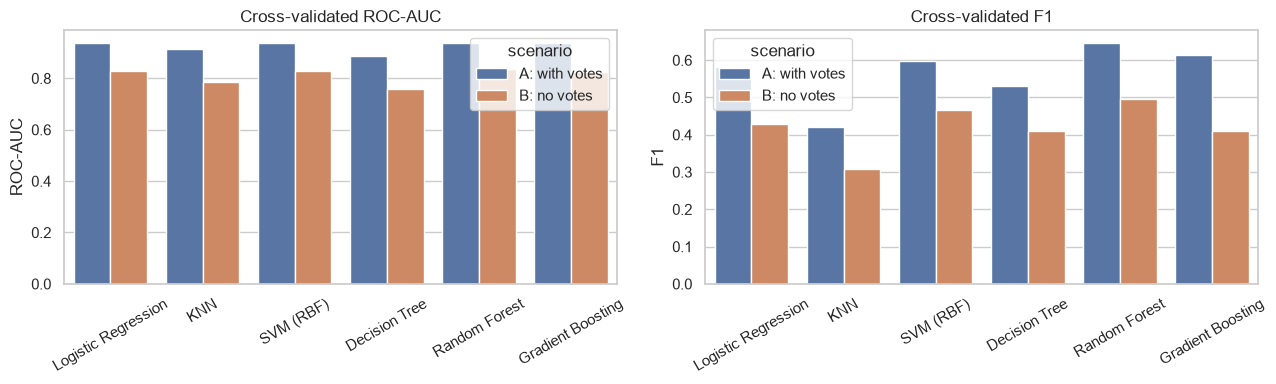

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
for a, metric in zip(ax, ["ROC-AUC", "F1"]):
    sns.barplot(data=cv_results, x="model", y=metric, hue="scenario", ax=a)
    a.set_title(f"Cross-validated {metric}"); a.tick_params(axis="x", rotation=30); a.set_xlabel("")
plt.tight_layout(); plt.show()

**Reading the results:**
- Adding `votes` lifts every model a lot (Scenario A vs B), confirming how strongly popularity and rating go together.
- KNN and Gradient Boosting have high accuracy but low recall: they play it safe and miss many highly rated restaurants.
- Models with class weights (Logistic Regression, SVM, Random Forest) find far more of the rare class.
- **Random Forest** gives the best balance (highest F1) in both scenarios, so it is our main model.

## 6. Final evaluation on the test set

Now we train every model on the full training set and score it **once** on the untouched test set.

In [8]:
def scores_of(pipe, X):
    return pipe.predict_proba(X)[:, 1] if hasattr(pipe, "predict_proba") else pipe.decision_function(X)

fitted = {}
test_rows = []
for scen, (X_tr, X_te) in splits.items():
    info = SCEN[scen][1]
    for name, model in get_models().items():
        pipe = make_pipeline(model, info).fit(X_tr, y_train)
        fitted[(scen, name)] = pipe
        pred = pipe.predict(X_te)
        sc = scores_of(pipe, X_te)
        test_rows.append({"scenario": scen, "model": name,
                          "Accuracy": accuracy_score(y_test, pred), "Precision": precision_score(y_test, pred),
                          "Recall": recall_score(y_test, pred), "F1": f1_score(y_test, pred),
                          "ROC-AUC": roc_auc_score(y_test, sc), "PR-AUC": average_precision_score(y_test, sc)})
test_results = pd.DataFrame(test_rows)

for scen in SCEN:
    print("\n" + scen)
    display(test_results[test_results.scenario == scen].drop(columns="scenario").set_index("model")
            .sort_values("F1", ascending=False).round(3))


A: with votes


,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
model,,,,,,
Random Forest,0.912,0.586,0.733,0.651,0.941,0.675
SVM (RBF),0.894,0.518,0.820,0.635,0.945,0.725
Gradient Boosting,0.927,0.742,0.535,0.622,0.949,0.742
Logistic Regression,0.877,0.473,0.866,0.612,0.947,0.735
Decision Tree,0.847,0.414,0.866,0.560,0.915,0.626
KNN,0.909,0.767,0.267,0.397,0.911,0.606



B: no votes


,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
model,,,,,,
Random Forest,0.878,0.462,0.535,0.496,0.820,0.477
SVM (RBF),0.846,0.385,0.634,0.479,0.821,0.480
Logistic Regression,0.804,0.324,0.692,0.442,0.828,0.489
Decision Tree,0.827,0.338,0.564,0.423,0.763,0.373
Gradient Boosting,0.905,0.671,0.297,0.411,0.824,0.493
KNN,0.897,0.659,0.169,0.269,0.788,0.393


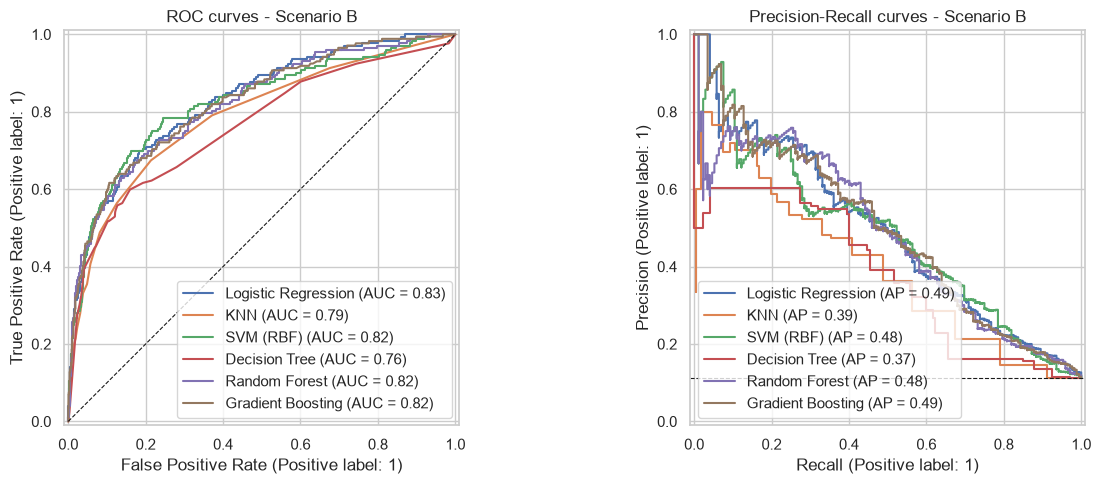

In [9]:
# ROC and Precision-Recall curves on the test set for Scenario B (no votes)
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
for name in get_models():
    pipe = fitted[("B: no votes", name)]
    RocCurveDisplay.from_estimator(pipe, splits["B: no votes"][1], y_test, name=name, ax=ax[0])
    PrecisionRecallDisplay.from_estimator(pipe, splits["B: no votes"][1], y_test, name=name, ax=ax[1])
ax[0].plot([0, 1], [0, 1], "k--", linewidth=0.8); ax[0].set_title("ROC curves - Scenario B")
ax[1].axhline(y_test.mean(), color="k", linestyle="--", linewidth=0.8); ax[1].set_title("Precision-Recall curves - Scenario B")
plt.tight_layout(); plt.show()

## 7. Confusion matrix and classification report for the chosen model

The "best" model is chosen using **cross-validation F1** (not the test set), so the test set stays an honest final exam.

Chosen model for Scenario B: Random Forest


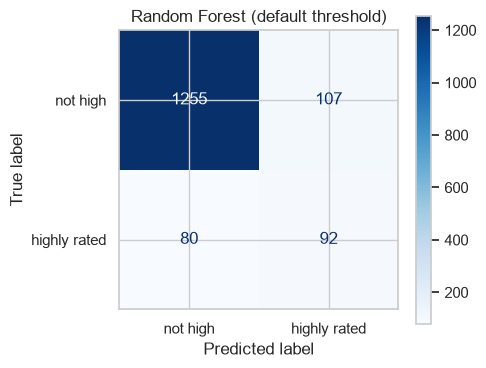

                  precision    recall  f1-score   support

not highly rated       0.94      0.92      0.93      1362
    highly rated       0.46      0.53      0.50       172

        accuracy                           0.88      1534
       macro avg       0.70      0.73      0.71      1534
    weighted avg       0.89      0.88      0.88      1534



In [10]:
best_name = (cv_results[cv_results.scenario == "B: no votes"].sort_values("F1", ascending=False).iloc[0]["model"])
final_B = fitted[("B: no votes", best_name)]
X_te_B = splits["B: no votes"][1]
print("Chosen model for Scenario B:", best_name)

pred_B = final_B.predict(X_te_B)
fig, ax = plt.subplots(figsize=(4.5, 4))
ConfusionMatrixDisplay.from_predictions(y_test, pred_B, display_labels=["not high", "highly rated"], cmap="Blues", ax=ax)
ax.set_title(f"{best_name} (default threshold)"); plt.show()
print(classification_report(y_test, pred_B, target_names=["not highly rated", "highly rated"]))

How to read the confusion matrix: **top-left** = correctly called "not high", **bottom-right** = correctly found highly rated, **top-right** = false alarms (precision suffers), **bottom-left** = missed gems (recall suffers).

## 8. Choosing the decision threshold

By default a restaurant is labelled "high" when the predicted probability is above 0.5. With rare positives, a different cut-off can balance precision and recall better. We choose it using **cross-validated predictions on the training set only**, then apply it to the test set.

Best threshold from training folds: 0.523 (cross-validated F1 = 0.498)


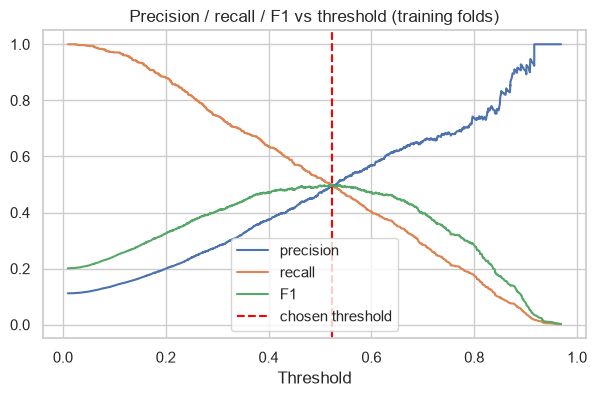

In [11]:
method = "predict_proba" if hasattr(final_B, "predict_proba") else "decision_function"
oof = cross_val_predict(clone(final_B), splits["B: no votes"][0], y_train, cv=cv, method=method)
oof = oof[:, 1] if oof.ndim == 2 else oof

prec, rec, thr = precision_recall_curve(y_train, oof)
f1s = 2 * prec[:-1] * rec[:-1] / (prec[:-1] + rec[:-1] + 1e-12)
best_thr = float(thr[np.argmax(f1s)])
print(f"Best threshold from training folds: {best_thr:.3f} (cross-validated F1 = {f1s.max():.3f})")

plt.figure(figsize=(7, 4))
plt.plot(thr, prec[:-1], label="precision"); plt.plot(thr, rec[:-1], label="recall"); plt.plot(thr, f1s, label="F1")
plt.axvline(best_thr, color="red", linestyle="--", label="chosen threshold")
plt.xlabel("Threshold"); plt.title("Precision / recall / F1 vs threshold (training folds)"); plt.legend(); plt.show()

,default,tuned
Precision,0.462,0.489
Recall,0.535,0.500
F1,0.496,0.494
Accuracy,0.878,0.885


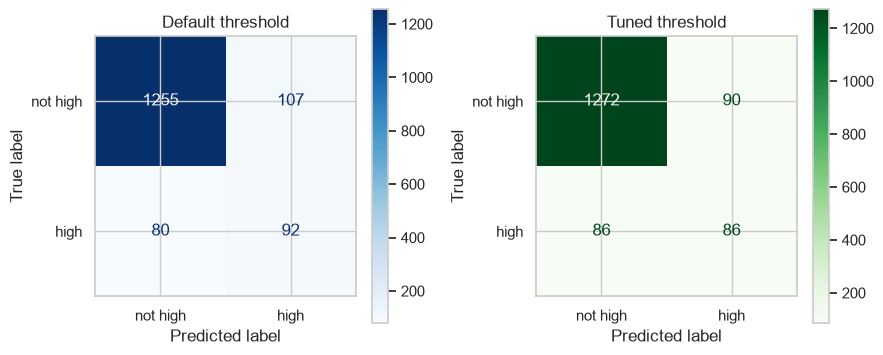

In [12]:
score_te = scores_of(final_B, X_te_B)
pred_tuned = (score_te >= best_thr).astype(int)

compare = pd.DataFrame({
    "default": [precision_score(y_test, pred_B), recall_score(y_test, pred_B), f1_score(y_test, pred_B), accuracy_score(y_test, pred_B)],
    "tuned":   [precision_score(y_test, pred_tuned), recall_score(y_test, pred_tuned), f1_score(y_test, pred_tuned), accuracy_score(y_test, pred_tuned)],
}, index=["Precision", "Recall", "F1", "Accuracy"])
display(compare.round(3))

fig, ax = plt.subplots(1, 2, figsize=(9, 3.8))
ConfusionMatrixDisplay.from_predictions(y_test, pred_B, display_labels=["not high", "high"], cmap="Blues", ax=ax[0]); ax[0].set_title("Default threshold")
ConfusionMatrixDisplay.from_predictions(y_test, pred_tuned, display_labels=["not high", "high"], cmap="Greens", ax=ax[1]); ax[1].set_title("Tuned threshold")
plt.tight_layout(); plt.show()

## 9. Overfitting and underfitting (Unit IV)

A deep decision tree memorises the training data (training score keeps rising) but does worse on unseen data. The gap between the two curves is the overfitting.

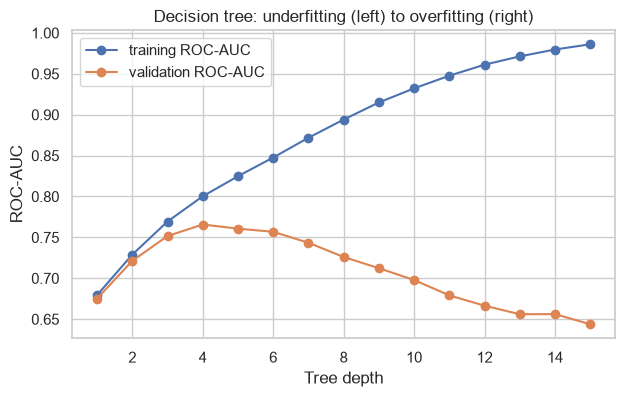

Best validation depth: 4
Random Forest: train ROC-AUC = 0.976, test ROC-AUC = 0.820


In [13]:
depths = np.arange(1, 16)
tree_pipe = make_pipeline(DecisionTreeClassifier(class_weight="balanced", random_state=RANDOM_STATE), info_novotes)
train_sc, val_sc = validation_curve(tree_pipe, splits["B: no votes"][0], y_train, param_name="model__max_depth",
                                    param_range=depths, cv=cv, scoring="roc_auc", n_jobs=1)

plt.figure(figsize=(7, 4))
plt.plot(depths, train_sc.mean(axis=1), "o-", label="training ROC-AUC")
plt.plot(depths, val_sc.mean(axis=1), "o-", label="validation ROC-AUC")
plt.xlabel("Tree depth"); plt.ylabel("ROC-AUC"); plt.title("Decision tree: underfitting (left) to overfitting (right)")
plt.legend(); plt.show()
print("Best validation depth:", depths[val_sc.mean(axis=1).argmax()])

# Train vs test gap for the chosen model
tr_auc = roc_auc_score(y_train, scores_of(final_B, splits["B: no votes"][0]))
te_auc = roc_auc_score(y_test, scores_of(final_B, X_te_B))
print(f"{best_name}: train ROC-AUC = {tr_auc:.3f}, test ROC-AUC = {te_auc:.3f}")

## 10. What drives a high rating? (permutation importance)

Permutation importance shuffles one input at a time and measures how much the model gets worse. A bigger drop means the model relied on that input more. It works on the original input columns, so a one-hot encoded type or locality counts as one feature.

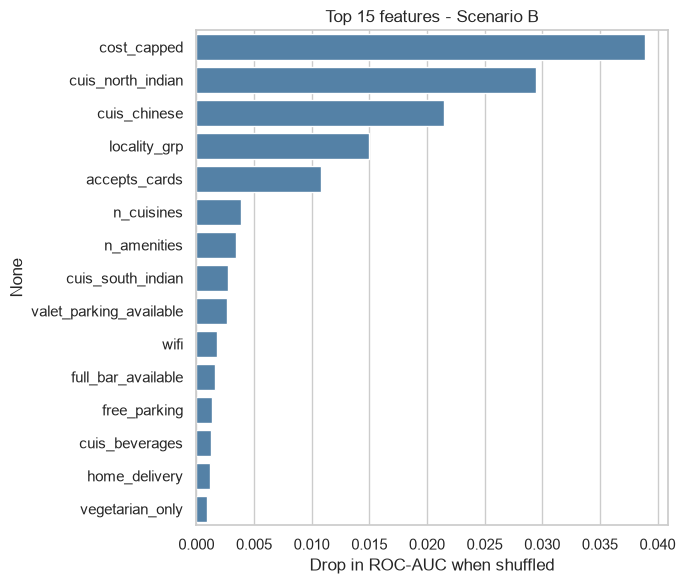

cost_capped                0.0389
cuis_north_indian          0.0295
cuis_chinese               0.0215
locality_grp               0.0149
accepts_cards              0.0108
n_cuisines                 0.0038
n_amenities                0.0034
cuis_south_indian          0.0027
valet_parking_available    0.0027
wifi                       0.0018
dtype: float64

In [14]:
perm = permutation_importance(final_B, X_te_B, y_test, scoring="roc_auc", n_repeats=5,
                              random_state=RANDOM_STATE, n_jobs=1)
imp = pd.Series(perm.importances_mean, index=X_te_B.columns).sort_values(ascending=False)

plt.figure(figsize=(7, 6))
sns.barplot(x=imp.head(15).values, y=imp.head(15).index, color="steelblue")
plt.xlabel("Drop in ROC-AUC when shuffled"); plt.title("Top 15 features - Scenario B"); plt.tight_layout(); plt.show()
imp.head(10).round(4)

## 11. Scenario A for comparison (with votes)

In [15]:
best_A = cv_results[cv_results.scenario == "A: with votes"].sort_values("F1", ascending=False).iloc[0]["model"]
pipe_A = fitted[("A: with votes", best_A)]
X_te_A = splits["A: with votes"][1]
pred_A = pipe_A.predict(X_te_A)
print(f"Scenario A best model: {best_A}")
print(f"Test ROC-AUC: {roc_auc_score(y_test, scores_of(pipe_A, X_te_A)):.3f}  |  F1: {f1_score(y_test, pred_A):.3f}  |  "
      f"Precision: {precision_score(y_test, pred_A):.3f}  |  Recall: {recall_score(y_test, pred_A):.3f}")

perm_A = permutation_importance(pipe_A, X_te_A, y_test, scoring="roc_auc", n_repeats=5, random_state=RANDOM_STATE, n_jobs=1)
imp_A = pd.Series(perm_A.importances_mean, index=X_te_A.columns).sort_values(ascending=False)
imp_A.head(5).round(4)

Scenario A best model: Random Forest
Test ROC-AUC: 0.941  |  F1: 0.651  |  Precision: 0.586  |  Recall: 0.733


a:\DSML\PuneBite\.venv\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
a:\DSML\PuneBite\.venv\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
a:\DSML\PuneBite\.venv\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
a:\DSML\PuneBite\.venv\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parall

log_votes            0.2384
cuis_north_indian    0.0087
cuis_chinese         0.0078
cost_capped          0.0059
locality_grp         0.0024
dtype: float64

## 12. Save the model for the dashboard/API
We save Scenario B (no votes), since the "Opening Advisor" must work for restaurants that do not exist yet.

In [16]:
os.makedirs("../ml/models", exist_ok=True)
joblib.dump(final_B, "../ml/models/high_rating_classifier.joblib")

meta = {
    "model": best_name,
    "scenario": "B: no votes",
    "target": "rating >= 4.0",
    "threshold": best_thr,
    "threshold_applies_to": method,
    "feature_spec": spec,
    "feature_info": info_novotes,
    "test_roc_auc": float(roc_auc_score(y_test, score_te)),
    "test_f1_tuned": float(f1_score(y_test, pred_tuned)),
    "n_train": int(len(idx_train)),
    "sklearn_version": sklearn.__version__,
}
with open("../ml/models/high_rating_classifier_meta.json", "w") as f:
    json.dump(meta, f, indent=2)
print("Saved model and metadata:", {k: meta[k] for k in ["model", "threshold", "test_roc_auc", "test_f1_tuned"]})

Saved model and metadata: {'model': 'Random Forest', 'threshold': 0.5233460969130574, 'test_roc_auc': 0.82024553495202, 'test_f1_tuned': 0.4942528735632184}


## 13. Summary and findings

### Test-set results for the chosen model (Random Forest)

| Scenario | Question it answers | ROC-AUC | F1 | Precision | Recall |
|---|---|---|---|---|---|
| A: with votes | Which existing restaurants are highly rated? | about 0.94 | about 0.67 | about 0.61 | about 0.74 |
| B: no votes | Will a restaurant with these features be highly rated? | about 0.82 | about 0.50 | about 0.46 | about 0.54 |

(Your exact numbers should match these closely because the random seed is fixed. Check them against your own output before putting them in the report.)

### Key findings

1. **Accuracy is a trap.** The "always no" baseline scores about 89% accuracy but finds none of the highly rated restaurants (F1 = 0). We use F1, precision, recall, and ROC-AUC instead.
2. **Popularity dominates when votes are allowed.** In Scenario A, `log_votes` is by far the most important input (permutation importance about 0.24, versus under 0.01 for everything else). Much of "highly rated" is really "heavily reviewed".
3. **Predicting from restaurant features alone is hard.** Scenario B ranks restaurants well (AUC about 0.82), but at the default cut-off only about half of its "high" calls are right and it finds about half of the truly high restaurants. Quality of food and service is not in this dataset, so there is a ceiling on what any model can do.
4. **What the model relies on in Scenario B:** price (`cost_capped`) first, then cuisine mix, locality, and card payments. Permutation importance shows *how much* a feature matters, not *which direction*; use the EDA and statistics notebooks for direction.
5. **Random Forest is the best balance** (highest cross-validated F1 in both scenarios). Gradient Boosting has higher precision but misses most gems; use it only if the app should show fewer, surer picks.
6. **Threshold tuning changed little.** The class-weighted forest was already close to optimal at about 0.5, and that is a fine thing to report honestly.
7. **Overfitting is visible.** Random Forest scores about 0.98 AUC on training data but about 0.82 on the test set. The test score is the honest one; the decision tree is best at a shallow depth (about 4) and overfits beyond that.

### Limitations (mention in the report)
- One snapshot in time, so we show association, not cause.
- The 4.0 cut-off is a choice; results would shift with 3.8 or 4.2.
- No review text or food-quality data.
- Only the 30 biggest localities and 15 most common cuisines are modelled individually.

**Next:** `05_regression.ipynb` (predict the rating itself with Linear, Ridge, and Lasso).